In [90]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


## Flavor


[0.7729496  0.96189284 1.11075721 1.24817047 1.35123042 1.43711371
 1.40848594]
[590.337044 485.337044 412.337044 364.337044 339.337044 317.337044
 325.337044]


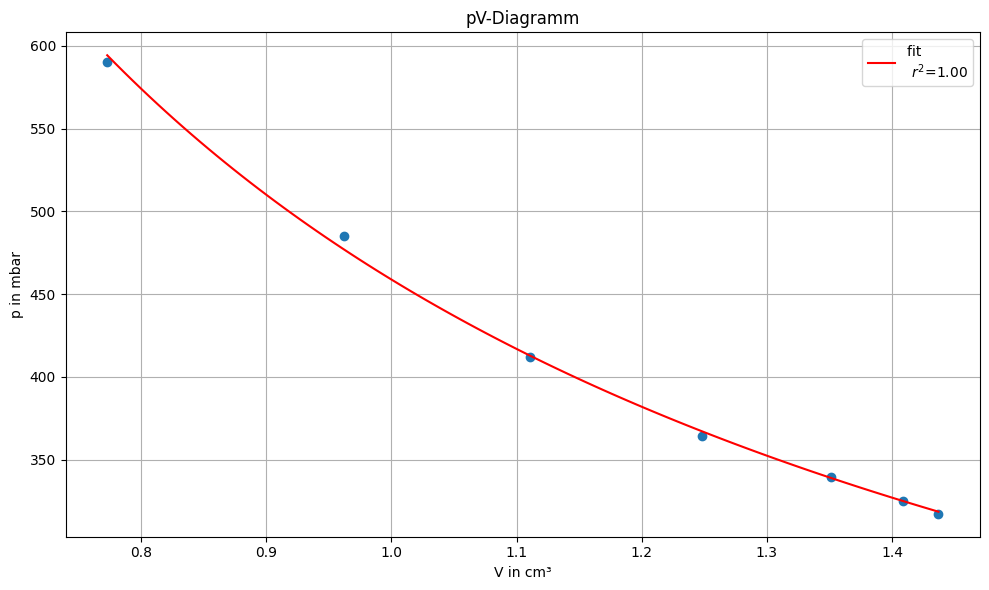

0.9984667164101162


In [102]:
# 2.2 Druck und Volumen konstante Temperatur

T_0 = 22       # °C
p_0 = 1002   # mbar
h_hg = 1        # cm

dp = 1002 - np.array([577, 472, 399, 351, 326, 304, 312, ])
h = np.array([13.5, 16.8, 19.4, 21.8, 23.6, 25.1, 24.6, ])

# Unsicherheiten
T_u = ufloat(22, 3)
p_u = ufloat(1002, 1) 



def Druck(dp, h, p_0):
    p_hg = c.g*h*136/100
    p = p_0 - dp + p_hg
    return p

def Volumen(h):
    V = c.pi*0.27**2*1/4*h
    return V

def model_f(x,a,b):
    return a/x + b


p = Druck(dp, h_hg, p_0)
V = Volumen(h)
print(V)
print(p)

popt, pcov = curve_fit(model_f, V, p, p0=[1,0])

a_opt, b_opt = popt
x_model = np.linspace(min(V), max(V), 100)
y_model = model_f(x_model, a_opt, b_opt)



def r2_curve_fit(popt, x, y):
    y_pred = model_f(x, *popt)
    r2 = r2_score(y, y_pred)
    return r2

r2 = r2_curve_fit(popt, V, p)


plt.figure(figsize=(10, 6))
plt.scatter(V, p)
plt.plot(x_model, y_model, color='r', label=f"fit \n $r^2$={r2:.2f}")
# plt.plot(V, p, "o")
plt.ylabel(r"p in mbar")
plt.xlabel(r"V in cm³")
plt.legend()
plt.title("pV-Diagramm")
plt.tight_layout()
plt.grid()
plt.show()
print(r2)

[0.51529974 0.52102529 0.50957418 0.50384863 0.49812308 0.49239752
 0.48667197 0.47522087 0.47522087 0.46376976]


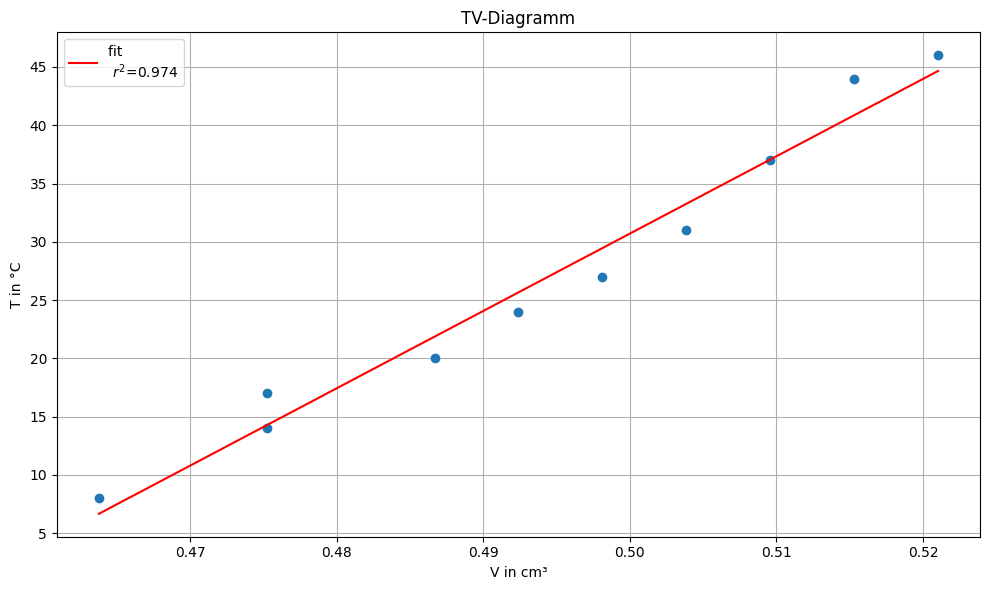

[44.0+/-3.0 46.0+/-3.0 37.0+/-3.0 31.0+/-3.0 27.0+/-3.0 24.0+/-3.0
 20.0+/-3.0 17.0+/-3.0 14.0+/-3.0 8.0+/-3.0]


In [97]:
# 2.2 Temperatur und Volumen konstante Druck


p_0 = ufloat(1000, 1)   # mbar

T = np.array([44, 46, 37, 31, 27, 24, 20, 17, 14, 8])      #°C
h = np.array([9.0, 9.1, 8.9, 8.8, 8.7, 8.6, 8.5, 8.3, 8.3, 8.1])   #cm

# Unsicherheiten
Tu = unp.uarray(T,3)
hu = unp.uarray(h,0.1)

def r2_curve_fit(func, popt, x, y):
    y_pred = func(x, *popt)
    r2 = r2_score(y, y_pred)
    return r2


def Volumen(h):
    V = c.pi*0.27**2*1/4*h
    return V
V = Volumen(h)
print(V)

def linfit(x, a, b):
    return a*x+b

popt, pcov = curve_fit(linfit, V, T, p0=[1,100])

a_opt, b_opt = popt
x_model = np.linspace(min(V), max(V), 100)
y_model = linfit(x_model, a_opt, b_opt)

r2 = r2_curve_fit(linfit, popt, V, T)

plt.figure(figsize=(10, 6))
plt.plot(V, T, "o")
plt.plot(x_model, y_model, color='r', label=f"fit \n $r^2$={r2:.3f}")
plt.ylabel(r"T in °C")
plt.xlabel(r"V in cm³")
plt.legend()
plt.title("TV-Diagramm")
plt.tight_layout()
plt.grid()
plt.show()
print(Tu)

## Flavor

In [104]:
# 3.2 Adiabatenexponent

T = unp.uarray([5.31, 5.37, 5.31, 5.50, 5.39, 5.58, 5.51, 5.64, 5.32, 5.56, 5.40, 5.43, 5.46, 5.32, 5.30], 0.01)/5    #s
p_0 = ufloat(1002, 1)              # mbar /pm 1
m = ufloat(16.7, 0.005)                # g     /pm 0.005
V_0 = 10*100**2                # l 
q = 8**2*c.pi           # mm^2
Tm = np.mean(T)
p = p_0 + ((m*c.g)/q)
print(Tm)
print(q, p)
K = ((2*c.pi/Tm)**2)*(m*V_0)/((q**2)*p)

print(K)


1.0853+/-0.0005
201.06192982974676 1002.8+/-1.0
1.3806+/-0.0019


In [110]:
# udruck

m = ufloat((7.8239)-(7.6647), 0.005) # g
h = ufloat(25.8, 2)   # cm
V = ufloat(61, 0.2)   # cm^3

print( f" {m} g Masse Probe, {h} cm Höhe Wassersäule, {V} cm^3 Luftvolumen")

 0.159+/-0.005 g Masse Probe, 25.8+/-2.0 cm Höhe Wassersäule, 61.00+/-0.20 cm^3 Luftvolumen
